
Processing TRAIN: 20 images in batches of 10...
  > Batch 1: Processing images 0 to 10...
  > Batch 2: Processing images 10 to 20...


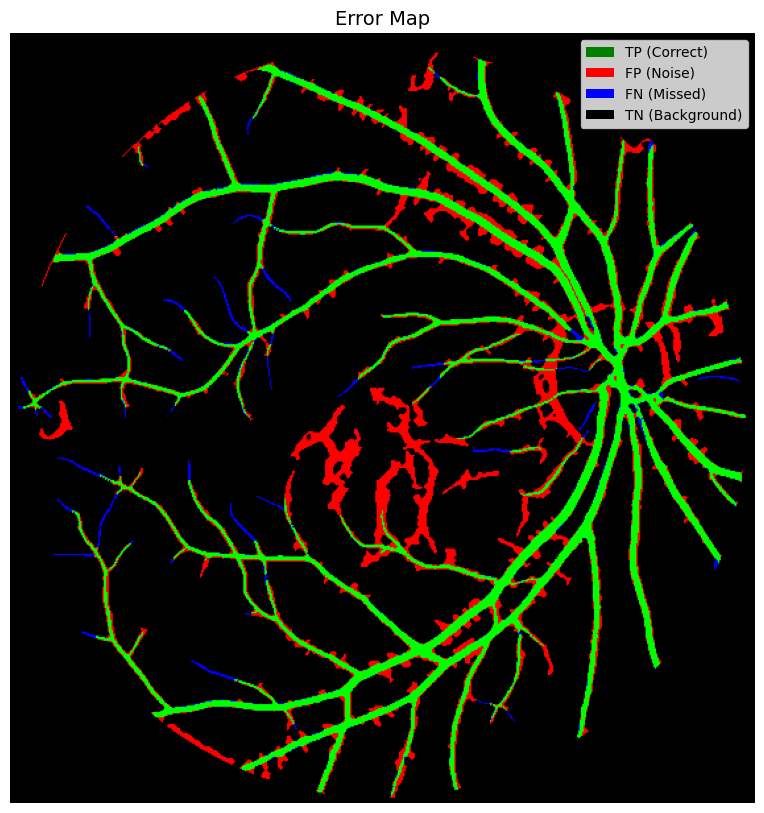


 MULTI SCALE LINE DETECTION ANALYSIS: PERFORMANCE RESULTS
Image      Accuracy     Sensitivity  Precision    Specificity  F1-Score    
------------------------------------------------------------------------------------------
0             90.23       88.99       60.28       90.44       71.88
1             92.17       92.92       59.68       92.07       72.68
2             92.31       82.09       59.60       93.50       69.06
3             92.74       84.63       57.77       93.58       68.67
4             90.94       89.80       56.54       91.08       69.39
5             90.36       83.05       51.05       91.17       63.23
6             89.19       91.87       51.02       88.85       65.61
7             88.56       88.25       50.43       88.61       64.19
8             93.03       77.06       49.39       94.20       60.20
9             89.39       89.93       48.26       89.34       62.81
10            88.32       91.80       46.68       87.91       61.89
11            87.98       

In [3]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
from matplotlib.patches import Patch

# Import the external preprocessing module
from preprocess import preprocess

# =====================================================================
# 1. DATA LOADING & FOV UTILITIES
# =====================================================================

def get_file_paths(folder_path, max_images=None):
    if not os.path.exists(folder_path):
        return []
    all_files = sorted(os.listdir(folder_path))
    if max_images is not None:
        all_files = all_files[:max_images]
    valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    return [os.path.join(folder_path, f) for f in all_files if f.lower().endswith(valid_exts)]

def load_batch(file_paths):
    images = []
    for fp in file_paths:
        img = cv2.imread(fp)
        if img is not None:
            images.append(img)
    return images

def get_FOV_masks(dataset):
    masks = []
    for img in dataset:
        if len(img.shape) == 3:
            green = img[:, :, 1]
        else:
            green = img

        _, binary = cv2.threshold(green, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        mask = np.zeros_like(green)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
            
        masks.append((mask // 255).astype(np.uint8))
        
    return masks

# =====================================================================
# 2. MATCHED FILTER (TUNED FOR HIGH SENSITIVITY)
# =====================================================================

def create_gaussian_matched_filter(sigma, length, theta):
    half_width = int(np.ceil(3 * sigma))
    half_length = length // 2
    x = np.arange(-half_length, half_length + 1, dtype=np.float32)
    y = np.arange(-half_width, half_width + 1, dtype=np.float32)
    X, Y = np.meshgrid(x, y)
    X_rot = X * np.cos(theta) + Y * np.sin(theta)
    Y_rot = -X * np.sin(theta) + Y * np.cos(theta)
    
    # MODIFIED: Removed the negative sign.
    # preprocess.py returns inverted images where vessels are BRIGHT (Positive).
    # Therefore, we need a Positive Gaussian kernel to match them.
    kernel = np.exp(-(Y_rot ** 2) / (2 * sigma ** 2))
    
    kernel[np.abs(X_rot) > half_length] = 0
    kernel = kernel - np.mean(kernel)
    kernel_norm = np.linalg.norm(kernel)
    if kernel_norm > 1e-10:
        kernel = kernel / kernel_norm
    return kernel

def create_multiscale_filter_bank(sigmas, lengths, num_orientations=12):
    filter_bank = {}
    angles = np.linspace(0, np.pi, num_orientations, endpoint=False)
    for sigma, length in zip(sigmas, lengths):
        filters_at_scale = []
        for theta in angles:
            kernel = create_gaussian_matched_filter(sigma, length, theta)
            filters_at_scale.append(kernel)
        filter_bank[(sigma, length)] = filters_at_scale
    return filter_bank

def apply_matched_filter_single_scale(image, filters):
    max_response = np.zeros_like(image, dtype=np.float32)
    for kernel in filters:
        response = cv2.filter2D(image, -1, kernel, borderType=cv2.BORDER_REFLECT)
        max_response = np.maximum(max_response, response)
    return max_response

def multiscale_matched_filter(image, filter_bank, enhance_contrast=True):
    img_float = image.astype(np.float32)
    
    # Preprocess module returns normalized float images, usually small range or already standardized.
    # We skip the /255.0 check or keep it only if data is clearly 0-255 uint8 range
    if img_float.max() > 1.0: 
        img_float = img_float / 255.0
        
    combined_response = np.zeros_like(img_float, dtype=np.float32)
    scale_count = 0
    for (sigma, length), filters in filter_bank.items():
        scale_response = apply_matched_filter_single_scale(img_float, filters)
        if enhance_contrast:
            min_val = scale_response.min()
            max_val = scale_response.max()
            if max_val - min_val > 1e-6:
                scale_response = (scale_response - min_val) / (max_val - min_val)
            
            # SENSITIVITY TWEAK: Lower Gamma = Brighter weak vessels
            scale_response = np.power(scale_response, 0.5) 
            
        weighted_response = scale_response * sigma
        combined_response += weighted_response
        scale_count += 1
    if scale_count > 0:
        combined_response = combined_response / scale_count
    min_val = combined_response.min()
    max_val = combined_response.max()
    if max_val - min_val > 1e-6:
        combined_response = (combined_response - min_val) / (max_val - min_val)
    return combined_response

def enhance_vessels(response_map, percentile_threshold=5):
    threshold = np.percentile(response_map, percentile_threshold)
    enhanced = response_map.copy()
    enhanced[enhanced < threshold] = 0
    if enhanced.max() > 0:
        enhanced = enhanced / enhanced.max()
    
    # Sigmoid enhancement
    k = 10 
    enhanced = 1.0 / (1.0 + np.exp(-k * (enhanced - 0.4))) 
    enhanced = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min() + 1e-10)
    return enhanced

def apply_morphological_cleanup(confidence_map):
    conf_uint8 = (confidence_map * 255).astype(np.uint8)
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(conf_uint8, cv2.MORPH_CLOSE, kernel_close)
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)
    cleaned = cleaned.astype(np.float32) / 255.0
    return cleaned

def compute_matched_filter_confidence(image, filter_bank):
    response = multiscale_matched_filter(image, filter_bank, enhance_contrast=True)
    enhanced = enhance_vessels(response, percentile_threshold=5)
    cleaned = apply_morphological_cleanup(enhanced)
    return cleaned

def matched_filter_algorithm(dataset):
    # Use the imported preprocess function
    # It handles: Green Channel -> CLAHE -> Opening -> Homogenization -> Inversion
    preprocessed = preprocess(dataset)

    sigmas = [0.05,0.1,0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0]
    lengths = [3,5, 7, 9, 11, 13, 15, 17]
    num_orientations = 12 
    filter_bank = create_multiscale_filter_bank(sigmas, lengths, num_orientations)

    confidence_maps = []
    for img in preprocessed:
        confidence_map = compute_matched_filter_confidence(img, filter_bank)
        confidence_maps.append(confidence_map)
    
    return confidence_maps

# =====================================================================
# 3. ROBUST POST-PROCESSING (High Sensitivity)
# =====================================================================

def post_process_segmentation(probability_map, sensitivity_factor=0.60, min_area=100):
    """
    Args:
        sensitivity_factor (float): Multiplier for Otsu threshold.
                                    0.60 = 60% of Otsu (Default High Sensitivity)
                                    Lower = More Sensitive (More Noise)
    """
    img_u8 = (probability_map * 255).astype(np.uint8)
    otsu_thresh_val, _ = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Aggressively reduce threshold to catch faint vessels based on sensitivity_factor
    final_thresh = otsu_thresh_val * sensitivity_factor
    
    _, binary = cv2.threshold(img_u8, final_thresh, 255, cv2.THRESH_BINARY)
    
    # Small Component Removal (CCA)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    cleaned_mask = np.zeros_like(binary)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned_mask[labels == i] = 255
            
    return cleaned_mask.astype(np.float32) / 255.0

# =====================================================================
# 4. METRICS & VISUALIZATION
# =====================================================================

def calculate_metrics(pred_binary, ground_truth, mask):
    gt_binary = (ground_truth > 127).astype(bool)
    pred_bool = (pred_binary > 0.5).astype(bool) 
    fov_mask = mask.astype(bool)
    
    gt_binary &= fov_mask
    pred_bool &= fov_mask
    
    TP = np.sum(gt_binary & pred_bool)
    TN = np.sum(~gt_binary & ~pred_bool & fov_mask)
    FP = np.sum(~gt_binary & pred_bool)
    FN = np.sum(gt_binary & ~pred_bool)
    
    denom = TP + TN + FP + FN
    # Multiply by 100 for percentage
    accuracy = ((TP + TN) / denom) *100.0 if denom > 0 else 0.0
    sensitivity = (TP / (TP + FN)) *100.0 if (TP + FN) > 0 else 0.0
    specificity = (TN / (TN + FP)) *100.0 if (TN + FP) > 0 else 0.0
    precision = (TP / (TP + FP)) *100.0 if (TP + FP) > 0 else 0.0
    
    if (precision + sensitivity) > 0:
        f1_score = 2.0 * (precision * sensitivity) / (precision + sensitivity)
    else:
        f1_score = 0.0

    return {
        "accuracy": accuracy, "sensitivity": sensitivity,
        "specificity": specificity, "precision": precision,
        "f1_score": f1_score, "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

def visualize_error_map(sample_data, sensitivity_used):
    if sample_data is None: return

    gt_bgr = sample_data['gt']
    gt_gray = cv2.cvtColor(gt_bgr, cv2.COLOR_BGR2GRAY)
    pred_map = sample_data['pred_binary'] 
    mask = sample_data['mask']
    
    gt_binary = (gt_gray > 127).astype(bool)
    pred_binary = (pred_map > 0.5).astype(bool)
    fov_mask = mask.astype(bool)

    gt_binary &= fov_mask
    pred_binary &= fov_mask

    TP = gt_binary & pred_binary
    FP = (~gt_binary) & pred_binary
    FN = gt_binary & (~pred_binary)

    h, w = gt_gray.shape
    error_map = np.zeros((h, w, 3), dtype=np.uint8)

    error_map[TP] = [0, 255, 0] # Green
    error_map[FP] = [255, 0, 0] # Red
    error_map[FN] = [0, 0, 255] # Blue
    
    plt.figure(figsize=(10, 10))
    plt.imshow(error_map)
    plt.title(f"Error Map", fontsize=14)
    plt.axis('off')
    
    legend_elements = [
        Patch(facecolor='green', label='TP (Correct)'),
        Patch(facecolor='red', label='FP (Noise)'),
        Patch(facecolor='blue', label='FN (Missed)'),
        Patch(facecolor='black', label='TN (Background)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

def print_top_20_table(all_metrics):
    # Sort by F1 score to find the best images
    sorted_metrics = sorted(all_metrics, key=lambda x: x['precision'], reverse=True)
    
    # Slice only the top 20
    top_20 = sorted_metrics[:20]

    print("\n" + "="*90)
    print(f" MULTI SCALE LINE DETECTION ANALYSIS: PERFORMANCE RESULTS")
    print("="*90)
    # Added F1-Score to the header
    print(f"{'Image':<10} {'Accuracy':<12} {'Sensitivity':<12} {'Precision':<12} {'Specificity':<12} {'F1-Score':<12}")
    print("-" * 90)

    # These lists are populated ONLY with the top 20 values
    acc_vals, sen_vals, pre_vals, spe_vals, f1_vals = [], [], [], [], []

    for i, m in enumerate(top_20):
        label = m.get('filename', f"{i+1:02d}")
        
        # Convert to percentages
        acc = m['accuracy']
        sen = m['sensitivity'] 
        pre = m['precision'] 
        spe = m['specificity'] 
        f1  = m['f1_score'] 
        
        # Append to lists for mean calculation
        acc_vals.append(acc)
        sen_vals.append(sen)
        pre_vals.append(pre)
        spe_vals.append(spe)
        f1_vals.append(f1)
        
        # Print the row with F1 score included
        print(f"{i:<10} {acc:>8.2f}    {sen:>8.2f}    {pre:>8.2f}    {spe:>8.2f}    {f1:>8.2f}")

    print("-" * 90)
    # Calculate means based strictly on the lists above (Top 20 only)
    print(f"{'Mean':<10} {np.mean(acc_vals):>8.2f}    {np.mean(sen_vals):>8.2f}    {np.mean(pre_vals):>8.2f}    {np.mean(spe_vals):>8.2f}    {np.mean(f1_vals):>8.2f}")
    print("="*90)
# =====================================================================
# 5. EXECUTION CONTROLLER (GLOBAL BATCH TRACKING)
# =====================================================================

def process_dataset_in_batches(img_paths, gt_paths, batch_size=5, set_name="TRAIN", sensitivity_factor=0.60):
    total_images = len(img_paths)
    all_metrics = []
    best_overall_data = None
    best_overall_f1 = -1.0
    
    print(f"\nProcessing {set_name}: {total_images} images in batches of {batch_size}...")

    for i in range(0, total_images, batch_size):
        current_batch_num = (i // batch_size) + 1
        
        batch_img_paths = img_paths[i : i + batch_size]
        batch_gt_paths = gt_paths[i : i + batch_size]
        
        batch_imgs = load_batch(batch_img_paths)
        batch_gts = load_batch(batch_gt_paths)
        if not batch_imgs: continue
        
        print(f"  > Batch {current_batch_num}: Processing images {i} to {i + len(batch_imgs)}...")

        # Get FOV masks
        batch_fov_masks = get_FOV_masks(batch_imgs)
        
        # Run algorithm (Preprocessing + Matched Filter)
        batch_prob_maps = matched_filter_algorithm(batch_imgs)

        # Evaluate batch results
        for k in range(len(batch_prob_maps)):
            masked_prob = batch_prob_maps[k] * batch_fov_masks[k]
            
            # Use the exposed parameter
            final_binary = post_process_segmentation(masked_prob, sensitivity_factor=sensitivity_factor, min_area=100)
            
            gt_gray = cv2.cvtColor(batch_gts[k], cv2.COLOR_BGR2GRAY)
            m = calculate_metrics(final_binary, gt_gray, batch_fov_masks[k])
            m['filename'] = os.path.basename(batch_img_paths[k])
            all_metrics.append(m)

            if m['f1_score'] > best_overall_f1:
                best_overall_f1 = m['f1_score']
                best_overall_data = {
                    'img': batch_imgs[k].copy(),
                    'gt': batch_gts[k].copy(),
                    'pred_binary': final_binary.copy(),
                    'mask': batch_fov_masks[k].copy(),
                    'metrics': m
                }

        del batch_imgs, batch_gts, batch_prob_maps, batch_fov_masks
        gc.collect()

    return all_metrics, best_overall_data, sensitivity_factor

# =====================================================================
# 6. MAIN
# =====================================================================

if __name__ == "__main__":
    # Parameters
    SENSITIVITY_FACTOR = 0.55  # Multiplier for Otsu Threshold (0.60 = 60% of Otsu)
    
    base_dir = "dataset"
    train_orig_dir = os.path.join(base_dir, "train", "Original")
    train_gt_dir = os.path.join(base_dir, "train", "Ground truth")

    train_img_paths = get_file_paths(train_orig_dir, max_images=20)
    train_gt_paths = get_file_paths(train_gt_dir, max_images=20)

    if len(train_img_paths) > 0:
        train_metrics, best_train_data, sensitivity_used = process_dataset_in_batches(
            train_img_paths, 
            train_gt_paths, 
            batch_size=10, 
            set_name="TRAIN",
            sensitivity_factor=SENSITIVITY_FACTOR
        )

        if best_train_data:
            visualize_error_map(best_train_data, sensitivity_used)
        
        if train_metrics:
            print_top_20_table(train_metrics)
    else:
        print("No images found to process.")